# ARoF Symb-ETDKAN-DPD - Hyperparameters optimization with Optuna

In [1]:
import sys
from pathlib import Path

file_path    = str(Path.cwd())
project_path = str(Path.cwd().parent.parent)

sys.path.append(project_path)

In [2]:
import pickle
import optuna
import numpy as np
import torch as th
import matplotlib.pyplot as plt

from functools                import partial
from scipy.signal             import welch, firwin, hilbert
from scipy.constants          import pi
from tqdm.notebook            import tqdm
from tabulate                 import tabulate

from optic.comm.ofdm          import modulateOFDM, demodulateOFDM
from optic.comm.modulation    import modulateGray
from optic.models.channels    import linearFiberChannel
from optic.models.devices     import mzm, photodiode
from optic.comm.metrics       import fastBERcalc, calcEVM
from optic.dsp.core           import pnorm, signal_power, finddelay, decimate, upsample, clockSamplingInterp
from optic.dsp.coreGPU        import firFilter
from optic.utils              import parameters, dBm2W

from dpd.nn                   import KAN_training
from dpd.utils                import power_amplifier, calcACLR
from dpd.torchUtils           import fitFilterNN
from dpd.optuna_tasks         import objective_dpd, get_pareto, getTrialParam

from optuna.trial             import TrialState
optuna.logging.set_verbosity(optuna.logging.WARNING)

In [3]:
font = {'size':14}
plt.rc('font', **font)
plt.rcParams["font.family"] = "serif"

In [4]:
symbTx    = np.loadtxt(project_path + r"\examples\transmittedSignal\symbTx.txt", dtype = np.complex64)
symbRx    = np.loadtxt(project_path + r"\examples\transmittedSignal\symbRx.txt", dtype = np.complex64)
sigTx_ref = np.loadtxt(project_path + r"\examples\transmittedSignal\sigTx.txt", dtype = np.complex64)
sigRx_PA  = np.loadtxt(project_path + r"\examples\transmittedSignal\sigRx_PA.txt", dtype = np.complex64)

In [5]:
with open(project_path + r"\examples\transmittedSignal\paramOFDM.pkl", 'rb') as f:
    paramOFDM = pickle.load(f)
    f.close()

with open(project_path + r"\examples\transmittedSignal\paramRF.pkl", 'rb') as f:
    paramRF = pickle.load(f)
    f.close()

with open(project_path + r"\examples\transmittedSignal\paramMZM.pkl", 'rb') as f:
    paramMZM = pickle.load(f)
    f.close()

with open(project_path + r"\examples\transmittedSignal\paramChannel.pkl", 'rb') as f:
    paramChannel = pickle.load(f)
    f.close()

with open(project_path + r"\examples\transmittedSignal\paramPD.pkl", 'rb') as f:
    paramPD = pickle.load(f)
    f.close()

### 1 - Geração do Sinal OFDM

In [6]:
# Param RoF
paramRoF = parameters()

paramRoF.paramOFDM    = paramOFDM
paramRoF.paramMZM     = paramMZM
paramRoF.paramChannel = paramChannel
paramRoF.paramRF      = paramRF
paramRoF.paramPD      = paramPD

### 3 Preparação do conjunto de dados de treinamento

In [7]:
SpS_DPD = 4
SpS = paramOFDM.SpS
Rs  = paramOFDM.Rs
Fs  = paramOFDM.Fs

device = 'cuda'

paramDec = parameters()
paramDec.SpS_in = SpS
paramDec.SpS_out = SpS_DPD

numtaps = 4096
hlp = firwin(numtaps, SpS_DPD*Rs/2, fs = Fs)

sigRef = decimate(pnorm(firFilter(hlp, sigTx_ref)), paramDec).ravel()
sigIn  = decimate(pnorm(firFilter(hlp, sigRx_PA)), paramDec).ravel()

delay = finddelay(sigIn, sigRef)
sigIn = np.roll(sigIn, -delay)

rot = np.mean(sigRef/sigIn)
sigIn = rot/np.abs(rot)*sigIn

In [8]:
sigRef = th.from_numpy(sigRef).to(device).type(th.complex64)
sigIn  = th.from_numpy(sigIn).to(device).type(th.complex64)

train_data = parameters()
train_data.sigRef = sigRef
train_data.sigIn  = sigIn
train_data.symbTx = symbTx

### 4 - Arquitetura de Aprendizado Indireto (ILA)

In [9]:
paramDPD = parameters()

paramDPD.model = "ETDKAN"
paramDPD.N = 50_000

paramDPD.divByL = 1
paramDPD.trainTestFrac = 0.75
paramDPD.shuffle = False

paramDPD.includeMemory = True
paramDPD.augment = False

paramDPD.device = device
paramDPD.pgrsBar = False
paramDPD.directLearn = False

paramDPD.batch_size = 1_000
paramDPD.lr = 5e-3
paramDPD.epochs = 100

paramDPD.SpS_DPD = SpS_DPD
paramDPD.Ntaps = 4
paramDPD.K = 0

paramDPD.k = 2
paramDPD.grid = 5
paramDPD.seed = 0
paramDPD.layers = [paramDPD.Ntaps, 5, paramDPD.Ntaps]

paramDPD.RoF_model = None
paramDPD.envelope  = True

paramDPD.pruning_epochs = [50]
paramDPD.symb = True

In [ ]:
n_trials  = 150
n_studies = np.array([1])
timeout   = 60*60*30
save      = True

search_space = {
    'N1': [i for i in range(1, 6)],
    'Ntaps': [i for i in range(2, 9, 2)],
    'grid': [2, 3, 4, 5, 6],
    'k': [2, 3, 4, 5, 6]
}

metrics = [ ["EVM", "NFLOPs"],
            ["ACLR", "NFLOPs"] ]

for i, std in enumerate(n_studies):

    description = f"""
    sampler: GridSampler 
    ntrials: {n_trials} 
    
    Hyperparameters range: 
    Ntaps: 2 - 8 (step of 2) 
    k: 2 - 6 
    grid: 2 - 6
    N1: 1 - 5 
    
    Obs.: {metrics[i][0]} and NFLOP as objective functions
    """
    
    with open(file_path + f"\\study{n_studies[i]}\\description.txt", "w") as description_file:
        description_file.write(description)
    
    objective_ILA = partial(objective_dpd, train_data = train_data, paramRoF = paramRoF, paramDPD = paramDPD, metrics = metrics[i], 
                            model_path = file_path + f"\\study{std}\\models")
    
    print(f"Study {std}:")
    #study_ILA = optuna.create_study(directions=["minimize", "minimize"], sampler = optuna.samplers.TPESampler())
    study_ILA = optuna.create_study(directions=["minimize", "minimize"], sampler = optuna.samplers.GridSampler(search_space))
    study_ILA.optimize(objective_ILA, n_trials = n_trials, timeout = timeout, show_progress_bar = True)
    
    complete_trials   = study_ILA.get_trials(deepcopy = False, states = [TrialState.COMPLETE])
    n_complete_trials = len(complete_trials)
    
    study_N1     = np.zeros(n_complete_trials)
    study_Ntaps  = np.zeros(n_complete_trials)
    study_k      = np.zeros(n_complete_trials)
    study_grid   = np.zeros(n_complete_trials)
    
    study_EVM    = np.zeros(n_complete_trials)
    study_ACLR   = np.zeros(n_complete_trials)
    study_NFLOPs = np.zeros(n_complete_trials)
    
    for j in range(n_complete_trials):
        trials_params    = complete_trials[j].params
        study_EVM[j]     = complete_trials[j].values[0]
        study_ACLR[j]    = complete_trials[j].values[1]
        study_NFLOPs[j]  = complete_trials[j].values[1]
        
        study_N1[j]    = trials_params["N1"]
        study_Ntaps[j] = trials_params["Ntaps"]
        study_k[j]     = trials_params["k"]
        study_grid[j]  = trials_params["grid"]
    
    if save:
        np.savetxt(file_path + f'\\study{std}\\parameters\\N1.txt', study_N1, fmt = '%f')
        np.savetxt(file_path + f'\\study{std}\\parameters\\Ntaps.txt', study_Ntaps, fmt = '%f')
        np.savetxt(file_path + f'\\study{std}\\parameters\\k.txt', study_k, fmt = '%f')
        np.savetxt(file_path + f'\\study{std}\\parameters\\grid.txt', study_grid, fmt = '%f')
        np.savetxt(file_path + f'\\study{std}\\results\\NFLOps.txt', study_NFLOPs, fmt = '%f')
        np.savetxt(file_path + f'\\study{std}\\results\\ACLR.txt', study_ACLR, fmt = '%f')
        np.savetxt(file_path + f'\\study{std}\\results\\EVM.txt', study_EVM, fmt = '%f')

In [19]:
study_EVM            = np.array([ np.loadtxt(file_path + f"\\study{1}\\models\\metrics_{j}.txt")[0] for j in range(n_trials) ])
study_NFLOPs_min_EVM = np.array([ np.loadtxt(file_path + f"\\study{1}\\models\\metrics_{j}.txt")[2] for j in range(n_trials) ])
study_NFLOPs_max_EVM = np.array([ np.loadtxt(file_path + f"\\study{1}\\models\\metrics_{j}.txt")[3] for j in range(n_trials) ])

study_ACLR            = np.array([ np.loadtxt(file_path + f"\\study{1}\\models\\metrics_{i}.txt")[1] for i in range(n_trials) ])
study_NFLOPs_min_ACLR = np.array([ np.loadtxt(file_path + f"\\study{1}\\models\\metrics_{j}.txt")[2] for j in range(n_trials) ])
study_NFLOPs_max_ACLR = np.array([ np.loadtxt(file_path + f"\\study{1}\\models\\metrics_{j}.txt")[3] for j in range(n_trials) ])

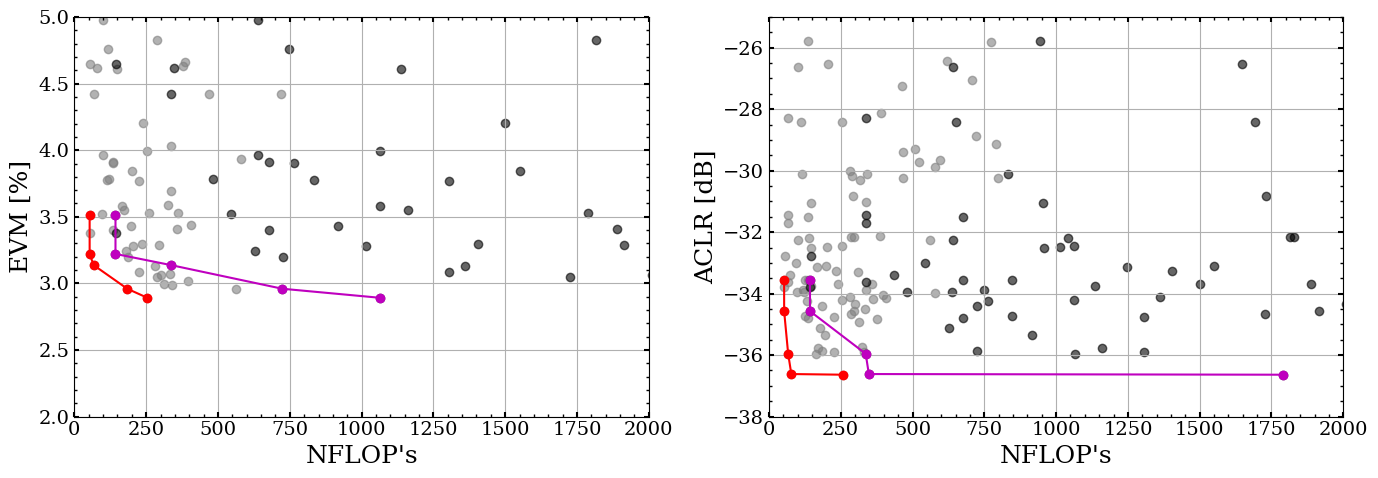

In [36]:
fig, axs = plt.subplots(1, 2, figsize = (14, 5))

n_trials_nan = np.sum(~np.isnan(study_EVM))

# EVM vs NFLOPs
pareto_solutions_evm_min, pareto_trials_evm_min = get_pareto(study_EVM[~np.isnan(study_EVM)], study_NFLOPs_min_EVM[~np.isnan(study_EVM)], n_trials_nan)
pareto_solutions_evm_max, pareto_trials_evm_max = get_pareto(study_EVM[~np.isnan(study_EVM)], study_NFLOPs_max_EVM[~np.isnan(study_EVM)], n_trials_nan)

axs[0].scatter(study_NFLOPs_min_EVM, study_EVM, color = "gray", alpha = 0.6)
axs[0].scatter(study_NFLOPs_max_EVM, study_EVM, color = "k", alpha = 0.6)
axs[0].plot(pareto_solutions_evm_min[:,1], pareto_solutions_evm_min[:,0], "-o", color = "r")
axs[0].plot(pareto_solutions_evm_max[:,1], pareto_solutions_evm_max[:,0], "-o", color = "m")

axs[0].set_xlim(0, 2e3)
axs[0].set_ylim(2., 5)
axs[0].set_xlabel("NFLOP's", fontsize = 18)
axs[0].set_ylabel("EVM [%]", fontsize = 18)

axs[0].minorticks_on()
axs[0].tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs[0].tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")
axs[0].grid()

# ACLR vs NFLOPs
pareto_solutions_aclr_min, pareto_trials_aclr_min = get_pareto(study_ACLR[~np.isnan(study_EVM)], study_NFLOPs_min_EVM[~np.isnan(study_EVM)], n_trials_nan)
pareto_solutions_aclr_max, pareto_trials_aclr_max = get_pareto(study_ACLR[~np.isnan(study_EVM)], study_NFLOPs_max_EVM[~np.isnan(study_EVM)], n_trials_nan)

axs[1].scatter(study_NFLOPs_min_ACLR, study_ACLR, color = "gray", alpha = 0.6)
axs[1].scatter(study_NFLOPs_max_ACLR, study_ACLR, color = "k", alpha = 0.6)
axs[1].plot(pareto_solutions_aclr_min[:,1], pareto_solutions_aclr_min[:,0], "-o", color = "r")
axs[1].plot(pareto_solutions_aclr_max[:,1], pareto_solutions_aclr_max[:,0], "-o", color = "m")

axs[1].set_xlim(0, 2e3)
axs[1].set_ylim(-38, -25)
axs[1].set_xlabel("NFLOP's", fontsize = 18)
axs[1].set_ylabel("ACLR [dB]", fontsize = 18)

axs[1].minorticks_on()
axs[1].tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs[1].tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")
axs[1].grid()

plt.tight_layout()
#plt.savefig(file_path + "\\Plots\\plot_pareto_EVM.png")

In [25]:
# Pareto Trials - EVM vs NFLOPs

for i, trial in enumerate(pareto_trials_evm_min):
    print(f"Trial {trial}: EVM = {study_EVM[trial]:.3f} %, NFLOPs = {study_NFLOPs_min_EVM[trial]}") 

Trial 2: EVM = nan %, NFLOPs = 493.0
Trial 3: EVM = nan %, NFLOPs = 401.0
Trial 4: EVM = nan %, NFLOPs = 635.0
Trial 5: EVM = 3.221 %, NFLOPs = 53.0
Trial 16: EVM = nan %, NFLOPs = 618.0
Trial 21: EVM = nan %, NFLOPs = 518.0
Trial 27: EVM = nan %, NFLOPs = 501.0
Trial 28: EVM = nan %, NFLOPs = 272.0
Trial 31: EVM = nan %, NFLOPs = 107.0
Trial 33: EVM = nan %, NFLOPs = 404.0
Trial 34: EVM = nan %, NFLOPs = 473.0
Trial 36: EVM = nan %, NFLOPs = 174.0
Trial 39: EVM = nan %, NFLOPs = 248.0
Trial 50: EVM = nan %, NFLOPs = 511.0
Trial 52: EVM = nan %, NFLOPs = 340.0
Trial 53: EVM = nan %, NFLOPs = 215.0
Trial 54: EVM = nan %, NFLOPs = 219.0
Trial 59: EVM = nan %, NFLOPs = 321.0
Trial 62: EVM = nan %, NFLOPs = 664.0
Trial 65: EVM = nan %, NFLOPs = 412.0
Trial 67: EVM = nan %, NFLOPs = 562.0
Trial 68: EVM = nan %, NFLOPs = 376.0
Trial 69: EVM = 2.892 %, NFLOPs = 254.0
Trial 70: EVM = nan %, NFLOPs = 215.0
Trial 71: EVM = nan %, NFLOPs = 218.0
Trial 74: EVM = nan %, NFLOPs = 351.0
Trial 75: EVM

In [48]:
trial_number = 75
param_trial = getTrialParam(trial_number, ["Ntaps", "N1", "k", "grid"], file_path + f"\study{1}\parameters")

Ntaps = 2.0
N1 = 1.0
k = 5.0
grid = 3.0


In [26]:
# Pareto Trials - ACLR vs NFLOPs

for i, trial in enumerate(pareto_trials_aclr_min):
    print(f"Trial {trial}: ACLR = {study_ACLR[trial]:.3f} dB, NFLOPs = {study_NFLOPs_min_ACLR[trial]}") 

Trial 2: ACLR = nan dB, NFLOPs = 493.0
Trial 3: ACLR = nan dB, NFLOPs = 401.0
Trial 4: ACLR = nan dB, NFLOPs = 635.0
Trial 5: ACLR = -33.566 dB, NFLOPs = 53.0
Trial 16: ACLR = nan dB, NFLOPs = 618.0
Trial 21: ACLR = nan dB, NFLOPs = 518.0
Trial 27: ACLR = nan dB, NFLOPs = 501.0
Trial 28: ACLR = nan dB, NFLOPs = 272.0
Trial 31: ACLR = nan dB, NFLOPs = 107.0
Trial 32: ACLR = -36.616 dB, NFLOPs = 78.0
Trial 33: ACLR = nan dB, NFLOPs = 404.0
Trial 34: ACLR = nan dB, NFLOPs = 473.0
Trial 36: ACLR = nan dB, NFLOPs = 174.0
Trial 39: ACLR = nan dB, NFLOPs = 248.0
Trial 50: ACLR = nan dB, NFLOPs = 511.0
Trial 52: ACLR = nan dB, NFLOPs = 340.0
Trial 53: ACLR = nan dB, NFLOPs = 215.0
Trial 54: ACLR = nan dB, NFLOPs = 219.0
Trial 59: ACLR = nan dB, NFLOPs = 321.0
Trial 62: ACLR = nan dB, NFLOPs = 664.0
Trial 65: ACLR = nan dB, NFLOPs = 412.0
Trial 67: ACLR = nan dB, NFLOPs = 562.0
Trial 68: ACLR = nan dB, NFLOPs = 376.0
Trial 70: ACLR = nan dB, NFLOPs = 215.0
Trial 71: ACLR = nan dB, NFLOPs = 218.

In [18]:
trial_number = 122
param_trial = getTrialParam(trial_number, ["Ntaps", "N1", "k", "grid"], file_path + f"\study{1}\parameters")

Ntaps = 4.0
N1 = 2.0
k = 6.0
grid = 3.0
